In [22]:
import numpy as np
import pandas as pd
from conda.core.initialize import initialize
from  sklearn.preprocessing import LabelEncoder,MinMaxScaler
from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,log_loss
import matplotlib.pyplot as plt
import seaborn as sns




In [23]:
df=pd.read_csv("../Datasets/Kyphosis.csv")
df.columns

Index(['Kyphosis', 'Age', 'Number', 'Start'], dtype='str')

In [24]:
print(df.shape)
print(df.head(2))

(81, 4)
  Kyphosis  Age  Number  Start
0   absent   71       3      5
1   absent  158       3     14


In [25]:
encoder = LabelEncoder()
y = encoder.fit_transform(df["Kyphosis"])
x=df.drop(columns=["Kyphosis"])


In [26]:
X_train,X_test,Y_train,Y_test=train_test_split(x,y,test_size=0.3,random_state=25,stratify=y)

In [27]:
min_max=MinMaxScaler().set_output(transform="pandas")
x_train_scaler=min_max.fit_transform(X_train)
x_test_scaler=min_max.transform(X_test)
print(x_train_scaler.shape)
print(x_test_scaler.shape)

(56, 3)
(25, 3)


In [28]:
x1,x2,x3=(x_train_scaler["Age"].values,x_train_scaler["Number"].values,x_train_scaler["Start"].values)
print(x1)

[0.57073171 0.67317073 0.94634146 0.86341463 0.62926829 0.03902439
 0.50731707 0.84878049 0.24390244 0.34146341 0.58536585 0.01463415
 0.54146341 0.00487805 0.67317073 0.17560976 0.57073171 0.39512195
 0.2        0.63414634 0.49268293 0.4195122  0.12682927 0.08292683
 0.16585366 0.81463415 0.24878049 0.03902439 0.44878049 0.
 0.61463415 0.06829268 0.34634146 0.         0.08292683 0.77073171
 0.6195122  0.04878049 0.69268293 0.76585366 0.10243902 0.85853659
 0.46829268 0.37560976 0.48292683 0.         0.46341463 0.28292683
 0.12195122 0.65853659 0.63414634 0.00487805 0.67804878 1.
 0.54634146 0.29268293]


In [29]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

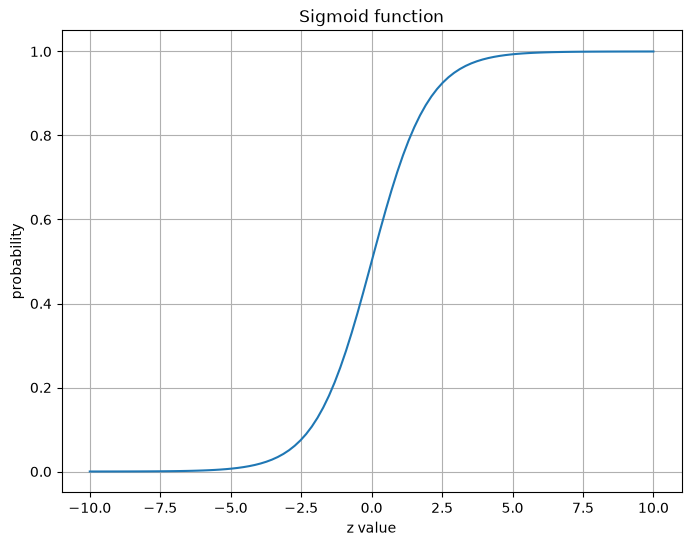

In [30]:
z=np.linspace(-10,10,100)
plt.figure(figsize=(8,6))
plt.plot(z,sigmoid(z),label="sigmoid")
plt.title("Sigmoid function")
plt.xlabel("z value")
plt.ylabel("probability")
plt.grid(True)
plt.show()

In [31]:
eta=0.1

w1,w2,w3=0.1,0.1,0.1
b=0.1

In [32]:
batch_loss=list()

for i in range(1000):

    # 1. Forward propagation
    y_curve = sigmoid(w1*x1 + w2*x2 + w3*x3 + b)

    # 2. Calculate loss
    l1 = log_loss(Y_train, y_curve)

    # 3. Store loss
    batch_loss.append(l1)

    if i % 100 == 0:
        print(f"{i}, loss: {l1}")

    # 4. Calculate gradients
    dw1 = np.mean((y_curve-Y_train)*x1)
    dw2 = np.mean((y_curve-Y_train)*x2)
    dw3 = np.mean((y_curve-Y_train)*x3)
    dv  = np.mean((y_curve-Y_train))

    # 5. Update parameters
    w1 = w1 - eta*dw1
    w2 = w2 - eta*dw2
    w3 = w3 - eta*dw3
    b  = b - eta*dv

0, loss: 0.7674577716028875
100, loss: 0.47274303601019113
200, loss: 0.4518340316647112
300, loss: 0.4370541197291132
400, loss: 0.42631632013051235
500, loss: 0.41845369849484293
600, loss: 0.41263895205146106
700, loss: 0.40829229971891573
800, loss: 0.4050078723976153
900, loss: 0.4025000346877302


In [33]:
print("Final batch is",batch_loss[-1])

Final batch is 0.4005830494671213


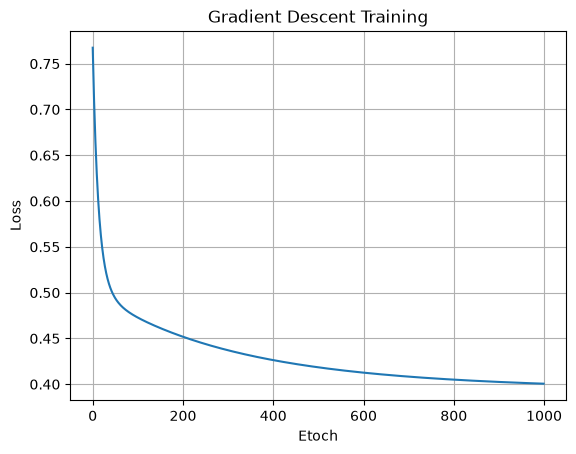

In [34]:
plt.Figure(figsize=(8,6))
plt.plot(batch_loss,label="Training Loss")
plt.title("Gradient Descent Training")
plt.xlabel("Etoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [35]:
y_preb_prop = sigmoid(
    w1*x_test_scaler["Age"] +
    w2*x_test_scaler["Number"] +
    w3*x_test_scaler["Start"] +
    b
)

print("Log Plot on test case \n", log_loss(Y_test, y_preb_prop))

Log Plot on test case 
 0.3936624208536274


In [36]:
y_pred = np.where(y_preb_prop > 0.5, 1, 0)
print(y_pred)

[0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0]


In [37]:
print(classification_report(Y_test,y_pred))

              precision    recall  f1-score   support

           0       0.83      0.95      0.88        20
           1       0.50      0.20      0.29         5

    accuracy                           0.80        25
   macro avg       0.66      0.57      0.58        25
weighted avg       0.76      0.80      0.76        25



In [38]:
y_train_std=Y_train
type(y_train_std)

numpy.ndarray

In [42]:
x1=x_train_scaler["Age"].values
x2=x_train_scaler["Number"].values
x3=x_train_scaler["Start"].values

In [43]:
eta=0.1
w1,w2,w3,b=0.1,0.1,0.1,0.1

In [44]:
sct_loss=[]
# random order
for j in range(1000):
    sct_random=np.random.permutation(len(x1))
    for i in sct_random:
        y_curve = sigmoid(w1*x1[i] + w2*x2[i] + w3*x3[i] + b)

        dw1=(y_curve-y_train_std[i])*x1[i]
        dw2=(y_curve-y_train_std[i])*x2[i]
        dw3=(y_curve-y_train_std[i])*x3[i]
        db=(y_curve-y_train_std[i])

        w1=w1-eta*dw1
        w2=w2-eta*dw2
        w3=w3- eta*dw3
        b=b-eta*db

    y_curve_final=sigmoid(w1*x1+w2*x2+w3*x3+b)
    l1=log_loss(Y_train,y_curve_final)
    sct_loss.append(l1)
    if j % 100 == 0:
        print(f"{j}, loss: {l1}")




0, loss: 0.49227225795504886
100, loss: 0.3942121983835323
200, loss: 0.3925277359584037
300, loss: 0.39315442735223194
400, loss: 0.3926638978792686
500, loss: 0.39252093895866574
600, loss: 0.39264956941315926
700, loss: 0.3928157031393566
800, loss: 0.3926645424369609
900, loss: 0.3925947751927065


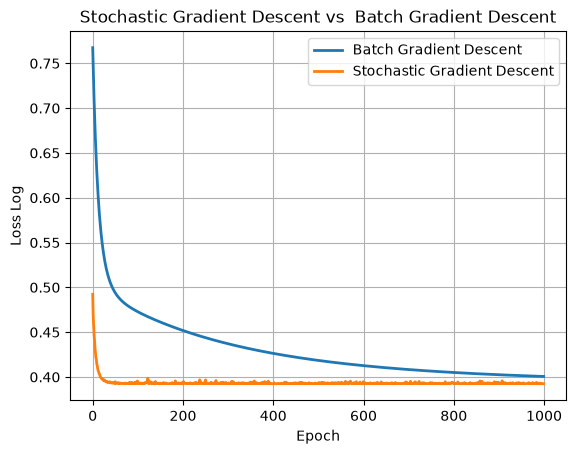

In [47]:
plt.Figure(figsize=(8,6))
plt.plot(batch_loss,label="Batch Gradient Descent",linewidth=2)
plt.plot(sct_loss,label="Stochastic Gradient Descent",linewidth=2)
plt.title("Stochastic Gradient Descent vs  Batch Gradient Descent")
plt.xlabel("Epoch")
plt.ylabel("Loss Log")
plt.grid(True)
plt.legend()
plt.show()


In [50]:
# mini batch
y_train_mb=Y_train

In [68]:
eta=0.1
batch_size=8
b,w1,w2,w3=0.1,0.1,0.1,0.1

In [69]:
mb_loss = list()

for i in range(1000):
    random_mb = np.random.permutation(len(x1))

    for start in range(0, len(random_mb), batch_size):
        random_start = random_mb[start:start + batch_size]

        xb_1 = x1[random_start]
        xb_2 = x2[random_start]
        xb_3 = x3[random_start]
        yb   = y_train_mb[random_start]

        y_curve = sigmoid(w1*xb_1 + w2*xb_2 + w3*xb_3 + b)

        # Gradients (np.mean correctly averages across the mini-batch)
        dw1 = np.mean((y_curve - yb) * xb_1)
        dw2 = np.mean((y_curve - yb) * xb_2)
        dw3 = np.mean((y_curve - yb) * xb_3)
        db  = np.mean(y_curve - yb)

        w1 -= eta * dw1
        w2 -= eta * dw2
        w3 -= eta * dw3
        b  -= eta * db

    y_curve_all = sigmoid(w1*x1 + w2*x2 + w3*x3 + b)

    l = log_loss(Y_train, y_curve_all)
    mb_loss.append(l)

    if i % 100 == 0:
        print(f"{i}, loss: {l}")





0, loss: 0.6511766660911753
100, loss: 0.40799220938480296
200, loss: 0.39613625237226413
300, loss: 0.3936931285868014
400, loss: 0.39298632170485764
500, loss: 0.39272967806634834
600, loss: 0.392619799038227
700, loss: 0.3925663563299778
800, loss: 0.392539366520752
900, loss: 0.3925250772732297


In [70]:
print(f"w 1={w1} w2={w2} w3={w3} b={b}")

w 1=1.2155273275645069 w2=2.3028059462528203 w3=-3.502460953882733 b=-0.7092190735048497


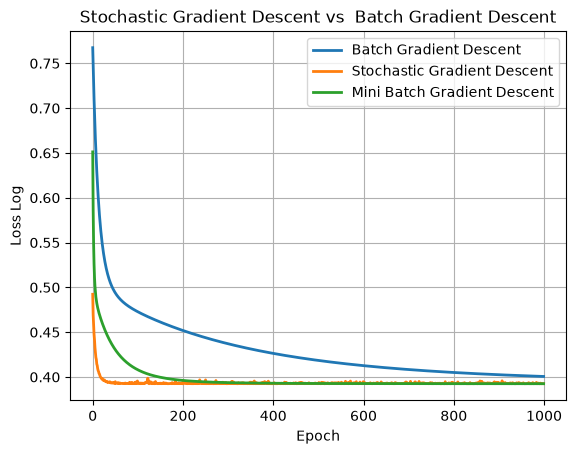

In [73]:
plt.Figure(figsize=(8,6))
plt.plot(batch_loss,label="Batch Gradient Descent",linewidth=2)
plt.plot(sct_loss,label="Stochastic Gradient Descent",linewidth=2)
plt.plot(mb_loss,label="Mini Batch Gradient Descent",linewidth=2)
plt.title("Stochastic Gradient Descent vs  Batch Gradient Descent")
plt.xlabel("Epoch")
plt.ylabel("Loss Log")
plt.grid(True)
plt.legend()
plt.show()